In [2]:
# Imports
import os
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from pymongo import MongoClient
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

# Set up logging so all steps are recorded to a file
logging.basicConfig(
    filename="pipeline.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)
logger.info("Pipeline started")
print("Setup complete")

Setup complete


# Querying MongoDB

In [3]:
load_dotenv()

try:
    # Connect to Atlas and pull all documents from the fires collection
    client = MongoClient(os.getenv("MONGO_URI"))
    collection = client["wildfires"]["fires"]
    docs = list(collection.find({}, {"_id": 0}))

    # Flatten nested weather and location sub-documents into columns
    df = pd.json_normalize(docs)

    logger.info(f"Loaded {len(df)} documents from MongoDB")
    print(f"Loaded {len(df)} documents")
    print(df.head())

except Exception as e:
    logger.error(f"Failed to load data from MongoDB: {e}")
    raise

Loaded 272091 documents
   fire_id      name state county  year  month  \
0        1  FOUNTAIN    CA     63  2005      2   
1        2    PIGEON    CA     61  2004      5   
2        3     SLACK    CA     17  2004      5   
3        4      DEER    CA      3  2004      6   
4        5  STEVENOT    CA      3  2004      6   

                                        cause  size_acres size_class  \
0  Power generation/transmission/distribution        0.10          A   
1                                     Natural        0.25          A   
2                     Debris and open burning        0.10          A   
3                                     Natural        0.10          A   
4                                     Natural        0.10          A   

   location.latitude  location.longitude  weather.avg_temp_f  \
0          40.036944         -121.005833               38.57   
1          38.933056         -120.404444               52.98   
2          38.984167         -120.735556          

# Data Preparation

In [4]:
try:
    # Define large fire as size class C or above (10+ acres)
    large_classes = ["C", "D", "E", "F", "G"]
    df["large_fire"] = df["size_class"].isin(large_classes).astype(int)

    # Encode state as a number since XGBoost needs numeric inputs
    df["state_encoded"] = (df["state"] == "CA").astype(int)  # CA=1, NV=0

    # Features to train on
    features = [
        "weather.avg_temp_f",
        "weather.avg_tmax_f",
        "weather.avg_tmin_f",
        "weather.avg_precip_in",
        "weather.avg_wind_mph",
        "month",
        "state_encoded"
    ]

    X = df[features]
    y = df["large_fire"]

    # 80/20 train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    logger.info(f"Train: {len(X_train)}, Test: {len(X_test)}, Large fire rate: {y.mean():.3f}")
    print(f"Train: {len(X_train)} | Test: {len(X_test)}")
    print(f"Large fire rate: {y.mean():.1%}")

except Exception as e:
    logger.error(f"Data preparation failed: {e}")
    raise

Train: 217672 | Test: 54419
Large fire rate: 7.7%


# XGBoost Model

In [5]:
try:
    # Compute class weight to correct for imbalance between small and large fires
    scale = (y_train == 0).sum() / (y_train == 1).sum()

    # Train the model
    model = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    )
    model.fit(X_train, y_train)

    logger.info("Model trained successfully")
    print("Model trained")

except Exception as e:
    logger.error(f"Model training failed: {e}")
    raise

Model trained


# Model Evaluation

In [6]:
try:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)

    logger.info(f"ROC-AUC: {auc:.4f}")
    print(f"ROC-AUC: {auc:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["Small Fire", "Large Fire"]))

except Exception as e:
    logger.error(f"Evaluation failed: {e}")
    raise

ROC-AUC: 0.6318

              precision    recall  f1-score   support

  Small Fire       0.94      0.67      0.78     50227
  Large Fire       0.11      0.51      0.18      4192

    accuracy                           0.65     54419
   macro avg       0.53      0.59      0.48     54419
weighted avg       0.88      0.65      0.73     54419



The first results were okay but not great. The main issue is that large fires make up only about 8% of the dataset, so I think the model sees way more small fires during training and gets biased toward predicting small. I can try to fix this by oversampling the large fire records using SMOTE, which creates synthetic examples of the minority class to balance things out.

In [7]:
try:
    from imblearn.over_sampling import SMOTE

    # Use SMOTE to create synthetic large fire examples and balance the training set
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

    logger.info(f"After SMOTE - class counts: {pd.Series(y_train_balanced).value_counts().to_dict()}")
    print(f"Balanced class counts:\n{pd.Series(y_train_balanced).value_counts()}")

    # Retrain on the balanced data
    model = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    )
    model.fit(X_train_balanced, y_train_balanced)

    # Re-evaluate
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    logger.info(f"Post-SMOTE ROC-AUC: {auc:.4f}")
    print(f"\nROC-AUC: {auc:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["Small Fire", "Large Fire"]))

except Exception as e:
    logger.error(f"SMOTE resampling failed: {e}")
    raise

/Users/sharinir/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Balanced class counts:
large_fire
1    200828
0    200828
Name: count, dtype: int64

ROC-AUC: 0.6307

              precision    recall  f1-score   support

  Small Fire       0.94      0.66      0.78     50227
  Large Fire       0.11      0.51      0.18      4192

    accuracy                           0.65     54419
   macro avg       0.53      0.59      0.48     54419
weighted avg       0.88      0.65      0.73     54419



SMOTE did not improve results meaningfully. The ROC-AUC stayed around 0.63 with both attempts. This seems to be more of a feature problem. Because weather values are averaged across an entire state by month, a small fire and a large fire that happened in the same state and month get identical weather features. The model has no way to tell them apart from weather alone. 

# Visualizations

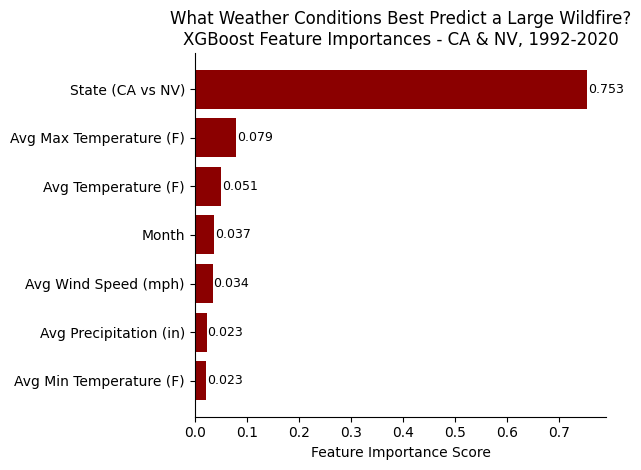

In [15]:
try:
    # Build a sorted dataframe of feature importances
    importance_df = pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=True)

    # Readable labels for the chart
    label_map = {
        "weather.avg_temp_f": "Avg Temperature (F)",
        "weather.avg_tmax_f": "Avg Max Temperature (F)",
        "weather.avg_tmin_f": "Avg Min Temperature (F)",
        "weather.avg_precip_in": "Avg Precipitation (in)",
        "weather.avg_wind_mph": "Avg Wind Speed (mph)",
        "month": "Month",
        "state_encoded": "State (CA vs NV)"
    }
    importance_df["feature"] = importance_df["feature"].map(label_map)

    # Plot
    fig, ax = plt.subplots()

    bars = ax.barh(
        importance_df["feature"],
        importance_df["importance"],
        color="darkred"
    )

    # Add score labels at the end of each bar
    for bar, val in zip(bars, importance_df["importance"]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9, color="black")

    ax.set_xlabel("Feature Importance Score")
    ax.set_title("What Weather Conditions Best Predict a Large Wildfire?\nXGBoost Feature Importances - CA & NV, 1992-2020")
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

    logger.info("Visualization rendered")

except Exception as e:
    logger.error(f"Visualization failed: {e}")
    raise

State (CA vs NV) dominates the model with an importance score of 0.753, meaning which state a fire occurred in was by far the strongest predictor. This makes sense given that California has significantly more fires and more extreme fire weather than Nevada. Weather variables like max temperature and wind speed contributed some signal but were much less influential on their own.

## Model Results Visual #1
The chart below shows the model's predicted probability of a large fire for every record in the test set, split by whether the fire was actually small or large.

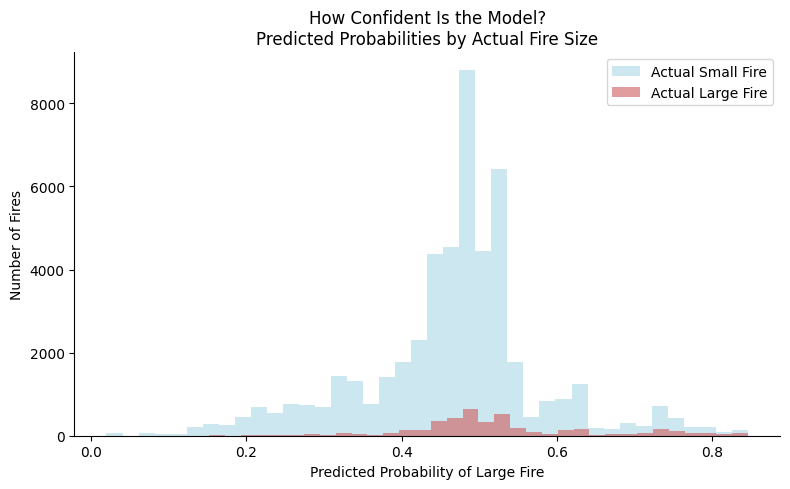

In [22]:
try:
    # Get predicted probabilities for the test set
    y_prob = model.predict_proba(X_test)[:, 1]

    # Separate probabilities by actual class
    prob_small = y_prob[y_test == 0]
    prob_large = y_prob[y_test == 1]

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(prob_small, bins=40, alpha=0.6, color="lightblue", label="Actual Small Fire")
    ax.hist(prob_large, bins=40, alpha=0.6, color="indianred", label="Actual Large Fire")
    ax.set_xlabel("Predicted Probability of Large Fire")
    ax.set_ylabel("Number of Fires")
    ax.set_title("How Confident Is the Model?\nPredicted Probabilities by Actual Fire Size")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

    logger.info("Probability distribution plot rendered")

except Exception as e:
    logger.error(f"Probability distribution plot failed: {e}")
    raise

Both small and large fires are predicted with probabilities clustered around 0.4 to 0.6, meaning the model is not very confident in either direction. The two distributions overlap heavily, which explains the modest ROC-AUC score. This again points back to the state level weather features not giving the model enough detail to clearly separate small fires from large ones.

## Model Results Visual #2:
The chart below takes the model's predicted probabilities and averages them by month. It shows which months the model flags as highest risk for a large wildfire. This directly supports the project goal of helping emergency managers know when to prepare and allocate resources in advance.

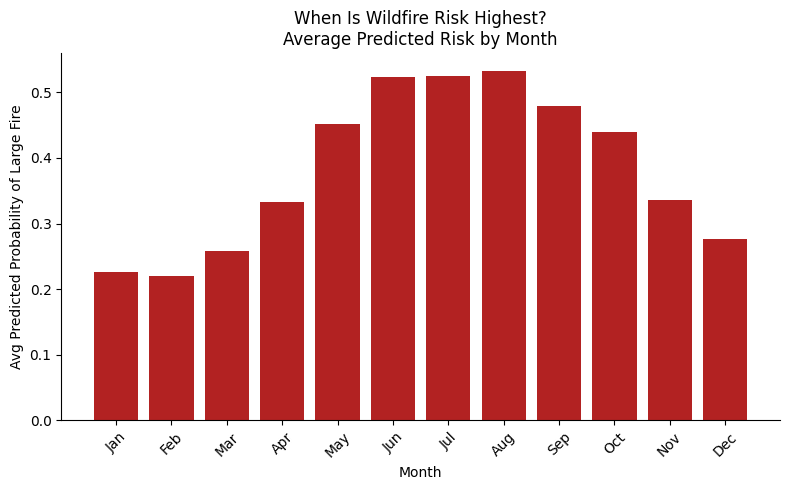

In [23]:
try:
    # Add predictions back to the test set to group by month
    test_df = X_test.copy()
    test_df["predicted_prob"] = y_prob

    monthly_risk = test_df.groupby("month")["predicted_prob"].mean()

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.bar(monthly_risk.index, monthly_risk.values, color="firebrick")
    ax.set_xlabel("Month")
    ax.set_ylabel("Avg Predicted Probability of Large Fire")
    ax.set_title("When Is Wildfire Risk Highest?\nAverage Predicted Risk by Month")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], rotation=45)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

    logger.info("Monthly risk plot rendered")

except Exception as e:
    logger.error(f"Monthly risk plot failed: {e}")
    raise

The model predicts wildfire risk peaks in June, July, and August, which lines up with what we know about fire season in California and Nevada. Risk drops off significantly in the winter months of January and February. This is one of the more important outputs from the model since it gives emergency managers a clear window of when to have resources ready.

# Rationales

## Analysis Rationale
I chose XGBoost as the model for this pipeline because it handles imbalanced datasets better than simpler models like logistic regression. My dataset has about 8% large fires and 92% small fires, so having a model that can account for that imbalance was important. XGBoost also produces feature importance scores, which let me directly answer the question of which weather conditions matter most for predicting fire size. I also tried SMOTE oversampling to further address the class imbalance, but it did not improve results. This showed that the features were the limiting factor rather than the training distribution.

## Visualization Rationale
I chose three visualizations that each show a different piece of the model's output. The feature importance chart was chosen because it directly answers which variables the model relied on most, which is useful for understanding the model's behavior. The predicted probability histogram was chosen because it shows how confident the model is across the full test set and makes the overlap between small and large fires visible in a way that a single accuracy number cannot. The monthly risk bar chart was chosen because it translates the model output into something meaningful for emergency responders. It shows a seasonal pattern that can help with planning decisions.

# Final Remarks

This model is not perfect, but it still tells a useful story. Even with state level weather averages as features, it was able to pick up on real patterns like the summer fire season peak and the difference in risk between California and Nevada. For emergency managers, knowing that August is consistently the highest risk month and that California fires tend to run larger is genuinely helpful for planning ahead. A future version of this project using weather data matched to actual fire locations would likely perform much better, but the foundation built here shows that publicly available data can support meaningful wildfire risk analysis.


In [24]:
# Log that the full pipeline ran without errors
logger.info("Pipeline completed successfully")
print("Done. Log written to pipeline.log")

Done. Log written to pipeline.log
